# Multidimensional QFT

This notebook runs the multidimensional QFT section by section, including padded non-power-of-two examples, Aer counts, and transpiled circuit views.


In [1]:
import numpy as np
from IPython.display import display
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

try:
    import matplotlib.pyplot as plt
    HISTOGRAMS_AVAILABLE = True
except Exception:
    plt = None
    HISTOGRAMS_AVAILABLE = False

from multidimensional_qft import (
    build_multidimensional_qft,
    dimension_qubit_widths,
    expected_multidimensional_qft_state,
    padded_shape,
    prepare_multidimensional_input,
    validate_shape,
)
from qft_sampler_utils import (
    build_measured_qft_circuit,
    sample_aer_counts,
    sample_noisy_aer_counts,
    select_fake_backend,
    total_variation_distance,
)
from qft_visualization_utils import show_circuit


def show_histogram(data, legend, title, top_n=12):
    print(f"\n{title}")
    all_labels = sorted({label for counts in data for label, value in counts.items() if value > 0})
    all_labels.sort(key=lambda label: sum(counts.get(label, 0) for counts in data), reverse=True)
    labels = all_labels[:top_n]

    if not HISTOGRAMS_AVAILABLE:
        print("matplotlib is not installed in this environment, so showing raw counts instead.")
        for series_label, counts in zip(legend, data):
            filtered = {label: counts.get(label, 0) for label in labels}
            print(series_label + ":", filtered)
        return

    width = 0.8 / max(len(data), 1)
    x = np.arange(len(labels), dtype=float)
    fig_width = max(12, len(labels) * 1.2)
    fig, ax = plt.subplots(figsize=(fig_width, 6))

    for index, (series_label, counts) in enumerate(zip(legend, data)):
        values = [counts.get(label, 0) for label in labels]
        offset = (index - (len(data) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width=width, label=series_label)
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    value + 0.5,
                    str(value),
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Counts")
    subtitle = f"Top {len(labels)} outcomes" if len(labels) < len(all_labels) else "All non-zero outcomes"
    ax.set_title(f"{title} ({subtitle})")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    if len(labels) < len(all_labels):
        print(f"Showing the top {len(labels)} outcomes out of {len(all_labels)} non-zero outcomes.")


In [2]:
shape = validate_shape((4, 2, 2))
shots = 128
sample_array = np.arange(1, np.prod(shape) + 1, dtype=float).reshape(shape, order="F")
padded_array, amplitudes = prepare_multidimensional_input(sample_array)
expected_state = expected_multidimensional_qft_state(sample_array)

padded = padded_shape(shape)
widths = dimension_qubit_widths(shape)
total_qubits = sum(widths)

standard_qft = build_multidimensional_qft(shape, method="standard")
recursive_qft = build_multidimensional_qft(shape, method="recursive")

print("Original shape:", shape)
print("Padded shape:", padded)
print("Dimension qubits:", widths)
print("Total qubits:", total_qubits)
print("\nInput array after padding:")
print(padded_array)


Original shape: (4, 2, 2)
Padded shape: (4, 2, 2)
Dimension qubits: [2, 1, 1]
Total qubits: 4

Input array after padding:
[[[ 1.+0.j  9.+0.j]
  [ 5.+0.j 13.+0.j]]

 [[ 2.+0.j 10.+0.j]
  [ 6.+0.j 14.+0.j]]

 [[ 3.+0.j 11.+0.j]
  [ 7.+0.j 15.+0.j]]

 [[ 4.+0.j 12.+0.j]
  [ 8.+0.j 16.+0.j]]]


In [3]:
standard_input = QuantumCircuit(total_qubits)
standard_input.initialize(amplitudes, range(total_qubits))
standard_input.compose(standard_qft, inplace=True)

recursive_input = QuantumCircuit(total_qubits)
recursive_input.initialize(amplitudes, range(total_qubits))
recursive_input.compose(recursive_qft, inplace=True)

standard_output = Statevector.from_instruction(standard_input).data
recursive_output = Statevector.from_instruction(recursive_input).data

print("Expected multidimensional DFT amplitudes:")
print(np.array2string(expected_state, precision=4, suppress_small=True))
print("\nStandard multidimensional QFT amplitudes:")
print(np.array2string(standard_output, precision=4, suppress_small=True))
print("\nRecursive multidimensional QFT amplitudes:")
print(np.array2string(recursive_output, precision=4, suppress_small=True))


Expected multidimensional DFT amplitudes:
[ 0.879 +0.j     -0.0517-0.0517j -0.0517+0.j     -0.0517+0.0517j
 -0.2068+0.j      0.    +0.j      0.    +0.j      0.    +0.j
 -0.4137+0.j      0.    +0.j      0.    +0.j      0.    +0.j
  0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]

Standard multidimensional QFT amplitudes:
[ 0.879 +0.j     -0.0517-0.0517j -0.0517+0.j     -0.0517+0.0517j
 -0.2068+0.j     -0.    +0.j      0.    +0.j     -0.    -0.j
 -0.4137+0.j     -0.    -0.j      0.    +0.j     -0.    +0.j
  0.    +0.j     -0.    -0.j     -0.    +0.j     -0.    +0.j    ]

Recursive multidimensional QFT amplitudes:
[ 0.879 +0.j     -0.0517-0.0517j -0.0517+0.j     -0.0517+0.0517j
 -0.2068+0.j     -0.    +0.j      0.    +0.j     -0.    -0.j
 -0.4137+0.j     -0.    -0.j      0.    +0.j     -0.    +0.j
  0.    +0.j     -0.    -0.j     -0.    +0.j     -0.    +0.j    ]



Standard multidimensional QFT


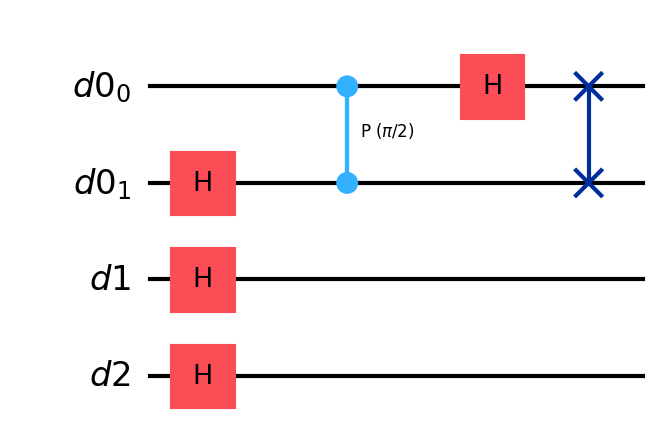


Recursive multidimensional QFT


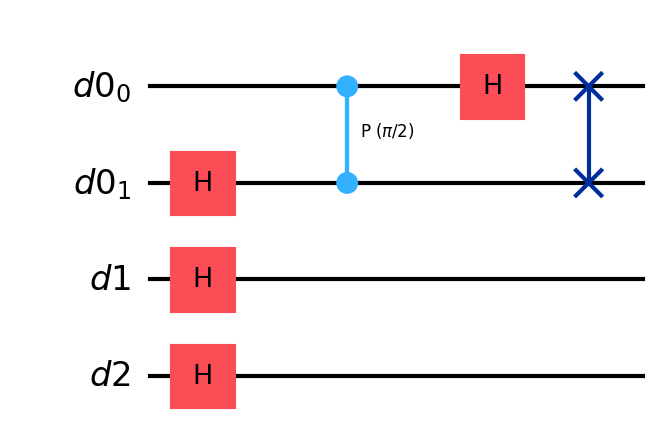

In [4]:
show_circuit(standard_qft, "Standard multidimensional QFT")
show_circuit(recursive_qft, "Recursive multidimensional QFT")


Using fake backend: fake_manila
Ideal Aer TVD between methods: 0.0469
Standard ideal vs noisy TVD: 0.2422
Recursive ideal vs noisy TVD: 0.2578

Multidimensional QFT ideal Aer counts


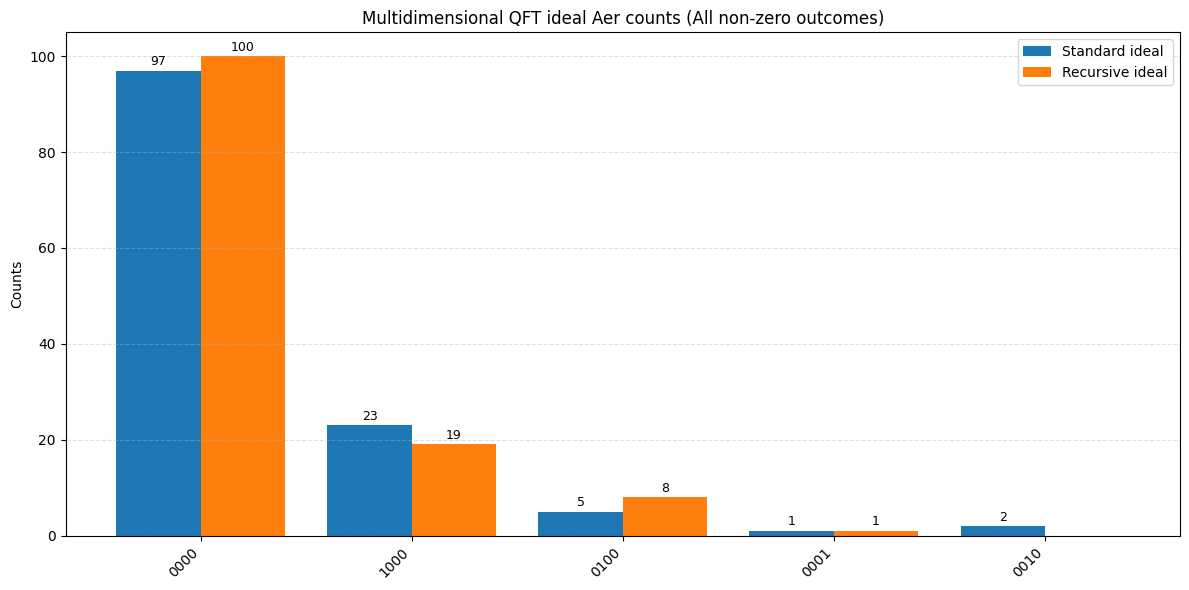


Multidimensional QFT noisy Aer counts


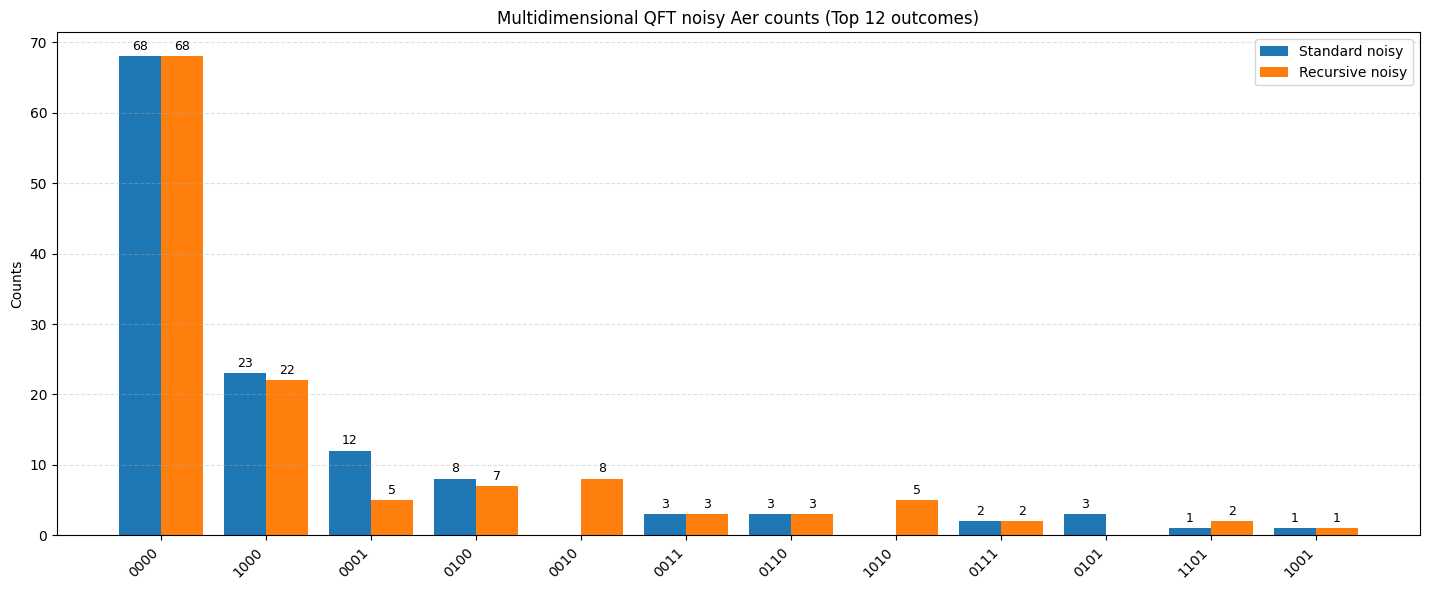

Showing the top 12 outcomes out of 16 non-zero outcomes.


In [5]:
backend = select_fake_backend(total_qubits)
print("Using fake backend:", backend.name)

standard_measured = build_measured_qft_circuit(amplitudes, standard_qft)
recursive_measured = build_measured_qft_circuit(amplitudes, recursive_qft)

standard_ideal_counts = sample_aer_counts(standard_measured, shots=shots)
recursive_ideal_counts = sample_aer_counts(recursive_measured, shots=shots)
standard_noisy_counts = sample_noisy_aer_counts(standard_measured, backend=backend, shots=shots)
recursive_noisy_counts = sample_noisy_aer_counts(recursive_measured, backend=backend, shots=shots)

print("Ideal Aer TVD between methods:", round(total_variation_distance(standard_ideal_counts, recursive_ideal_counts), 4))
print("Standard ideal vs noisy TVD:", round(total_variation_distance(standard_ideal_counts, standard_noisy_counts), 4))
print("Recursive ideal vs noisy TVD:", round(total_variation_distance(recursive_ideal_counts, recursive_noisy_counts), 4))

show_histogram([standard_ideal_counts, recursive_ideal_counts], legend=["Standard ideal", "Recursive ideal"], title="Multidimensional QFT ideal Aer counts")
show_histogram([standard_noisy_counts, recursive_noisy_counts], legend=["Standard noisy", "Recursive noisy"], title="Multidimensional QFT noisy Aer counts")



Standard multidimensional QFT transpiled


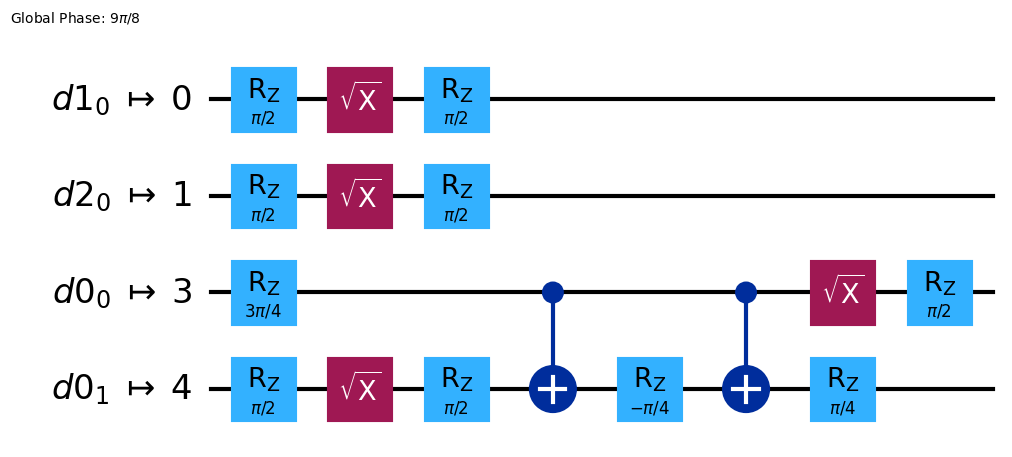


Recursive multidimensional QFT transpiled


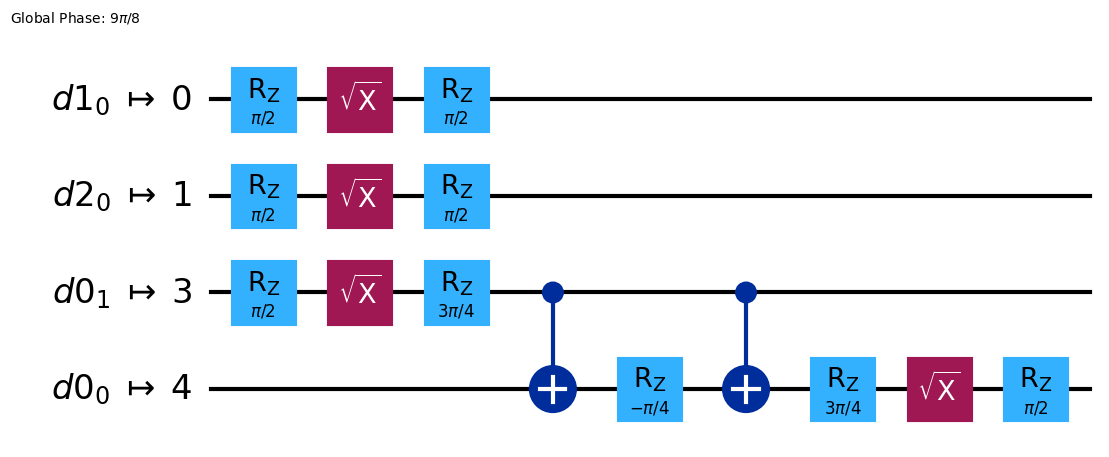

In [6]:
pass_manager = generate_preset_pass_manager(optimization_level=2, backend=backend)
show_circuit(pass_manager.run(standard_qft), "Standard multidimensional QFT transpiled")
show_circuit(pass_manager.run(recursive_qft), "Recursive multidimensional QFT transpiled")


## Padded Example

Change the shape below to try a non-power-of-two multidimensional input, for example `(3, 2)` or `(9, 4)`.


In [7]:
non_power_shape = validate_shape((3, 2))
non_power_array = np.arange(1, np.prod(non_power_shape) + 1, dtype=float).reshape(non_power_shape, order="F")
non_power_padded, non_power_amplitudes = prepare_multidimensional_input(non_power_array)
print("Original shape:", non_power_shape)
print("Padded shape:", padded_shape(non_power_shape))
print(non_power_padded)


Original shape: (3, 2)
Padded shape: (4, 2)
[[1.+0.j 4.+0.j]
 [2.+0.j 5.+0.j]
 [3.+0.j 6.+0.j]
 [0.+0.j 0.+0.j]]
